<a href="https://colab.research.google.com/github/mahmudulhasantechnology-cmyk/Streamlining-Taxi-Fare-Predictions-From-Outliers-to-API/blob/main/Streamlining-Taxi-Fare-Predictions-From-Outliers-to-API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# install neceassary library

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
df.shape

(6433, 2)

In [ ]:
df = df[["distance","fare"]]
df

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0
...,...,...
6428,0.75,4.5
6429,18.74,58.0
6430,4.14,16.0
6431,1.12,6.0


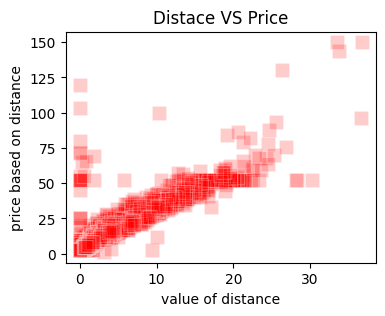

In [ ]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=df["distance"]  ,y = df["fare"], color ="r", marker="s", s=100, alpha=.2)
plt.xlabel("value of distance")
plt.ylabel("price based on distance")
plt.title("Distace VS Price")
plt.show()

from the given visualization we conclude that the value of fare is increased in a continous manner when the value of distance is increased. It goes from 0-30 but after 30 we sew some flactuations over fare and distance.

In [ ]:
df.isna().sum()

,0
distance,0
fare,0


In [ ]:
df.duplicated().sum()

np.int64(2978)

the given dataset donot have any NaN value but have a big number of duplicate value and we need to drop them, as because the proposed model will not be baised

# Data Clean

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3455 entries, 0 to 6432
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   distance  3455 non-null   float64
 1   fare      3455 non-null   float64
dtypes: float64(2)
memory usage: 81.0 KB


In [ ]:
df.describe()

,distance,fare
count,3455.000000,3455.000000
mean,4.365847,17.424420
std,4.617425,13.648461
min,0.000000,1.000000
25%,1.440000,8.500000
50%,2.680000,13.000000
75%,5.320000,21.000000
max,36.700000,150.000000


<Axes: >

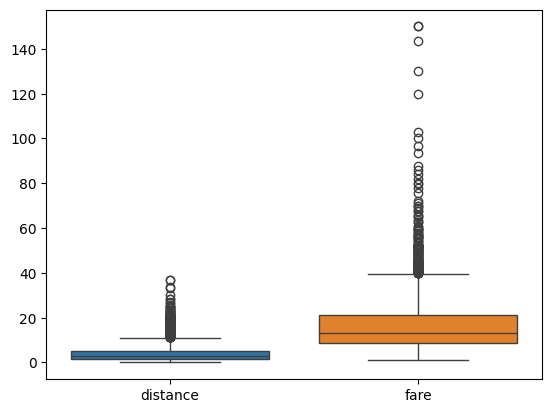

In [ ]:
sns.boxplot(df)

In [ ]:
x = df[["distance"]] # separate the data
y = df[["fare"]]

<Axes: >

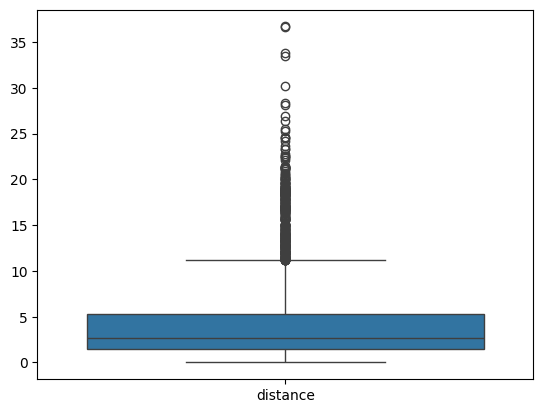

In [ ]:
sns.boxplot(x)

In [ ]:
#split the dataset
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest, ytrain, ytest = train_test_split(x,y,train_size=.8, random_state=42)

In [ ]:
xtrain.head(3)

,distance
1777,2.49
3808,5.18
2402,19.20


In [ ]:
ytrain.head(3)

,fare
1777,11.0
3808,20.0
2402,84.0


In [ ]:
#  model implement
from sklearn.linear_model import LinearRegression

In [ ]:
# instance of object
lr = LinearRegression()

In [ ]:
# train model
linear_model= lr.fit(xtrain, ytrain)

In [ ]:
linear_model

LinearRegression()

In [ ]:
# check train score
linear_model.score(xtrain, ytrain)

0.8356707954997834

In [ ]:
# test score
linear_model.score(xtest, ytest)

0.7794338799671384

In [ ]:
# prediction for the new data
linear_model.predict([[45]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[125.7443046]])

In [ ]:
y_pred = linear_model.predict(xtest)

In [ ]:
ytest

,fare
594,31.0
51,12.0
1586,12.0
3718,26.5
648,9.0
...,...
3644,103.0
724,5.0
5605,3.5
6402,11.5


In [ ]:
# evaluate the model
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

In [ ]:
r_sc= r2_score(ytest, y_pred)
r_sc

0.7794338799671384

In [ ]:
# cost calculation
mae = mean_absolute_error(ytest, y_pred)
mae

2.7033611531080877

In [ ]:
mse = mean_squared_error(ytest, y_pred)
mse

43.22049190547442